In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# For encoding categorical data
from sklearn.preprocessing import LabelEncoder

# For feature scaling
from sklearn.preprocessing import StandardScaler

# K-Means Clustering
from sklearn.cluster import KMeans

# Model Evaluation
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [3]:
# Shape of dataset

print("Shape of Dataset:")
print(df.shape)

# Information

print("\nDataset Information:")
print(df.info())

# Statistical Summary

print("\nSummary Statistics:")
print(df.describe())

# Check missing values

print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Summary Statistics:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000        

In [4]:
# Remove duplicate rows if present

df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(200, 5)


In [7]:
# Display all column names

print(df.columns)


Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [8]:
# Convert Male/Female into numbers

encoder = LabelEncoder()

df["Genre"] = encoder.fit_transform(df["Genre"])

print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1      1   19                  15                      39
1           2      1   21                  15                      81
2           3      0   20                  16                       6
3           4      0   23                  16                      77
4           5      0   31                  17                      40


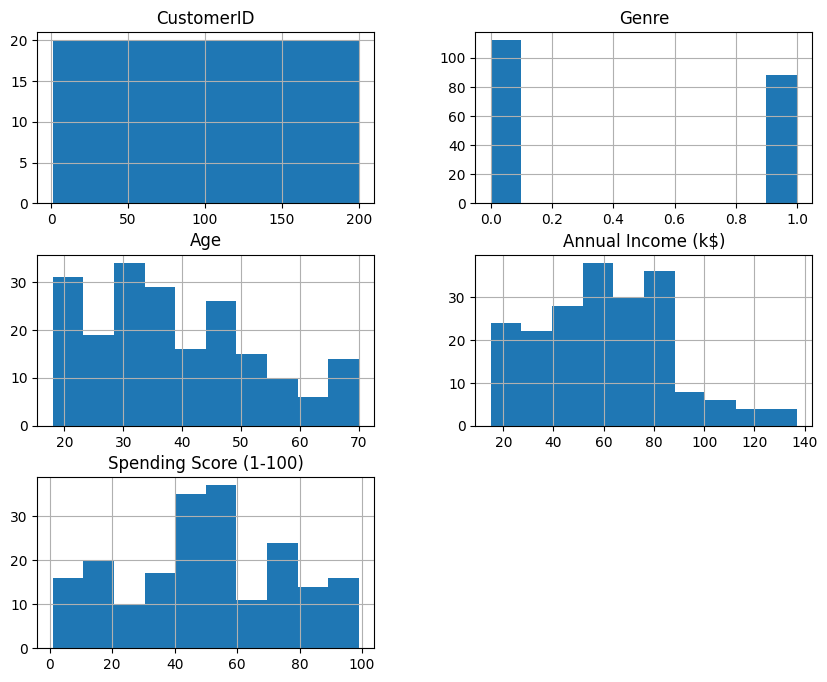

In [9]:
df.hist(figsize=(10,8))
plt.show()

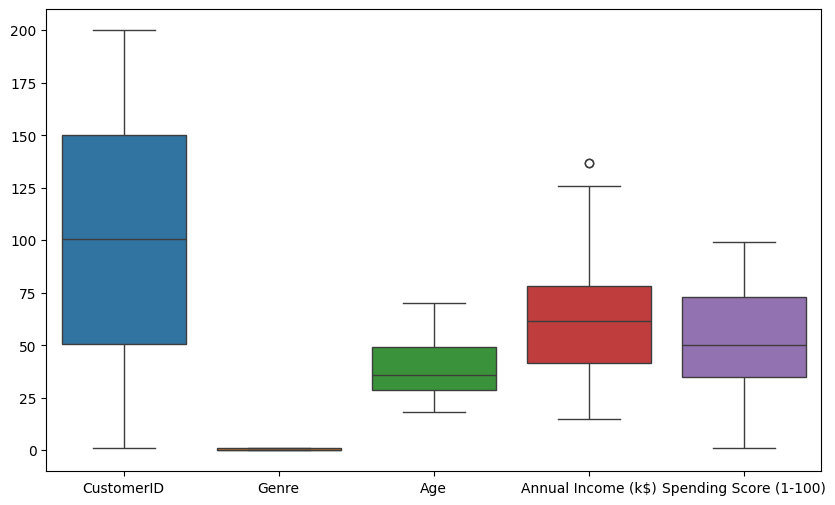

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df)

plt.show()

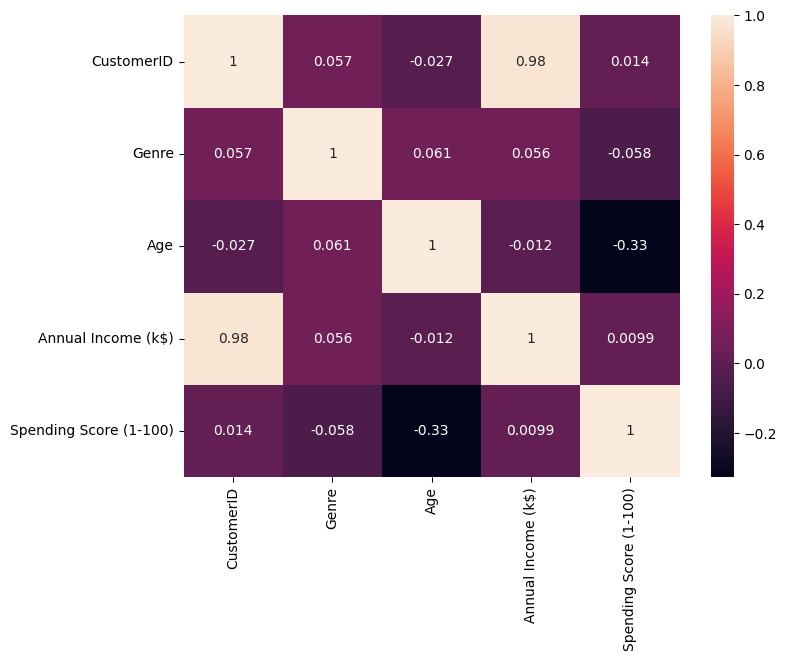

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True)

plt.show()

In [12]:
# Remove CustomerID because it is just an ID

X = df.drop("CustomerID", axis=1)

print(X.head())

   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0      1   19                  15                      39
1      1   21                  15                      81
2      0   20                  16                       6
3      0   23                  16                      77
4      0   31                  17                      40


In [13]:
# Scale the data

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

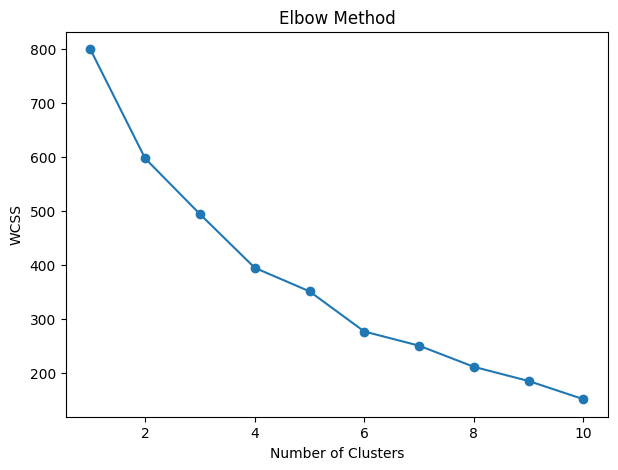

In [14]:
# Finding good clusters using Elbow method
wcss = []

# Try clusters from 1 to 10

for i in range(1,11):

    model = KMeans(n_clusters=i, random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

# Plot graph

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [15]:
# Create KMeans model

kmeans = KMeans(n_clusters=5, random_state=42)

# Predict cluster labels

clusters = kmeans.fit_predict(X_scaled)

# Add cluster column

df["Cluster"] = clusters

print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      1   19                  15                      39        2
1           2      1   21                  15                      81        2
2           3      0   20                  16                       6        4
3           4      0   23                  16                      77        4
4           5      0   31                  17                      40        4


In [16]:
# Calculate Silhouette Score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score =", score)

Silhouette Score = 0.27191023466188324


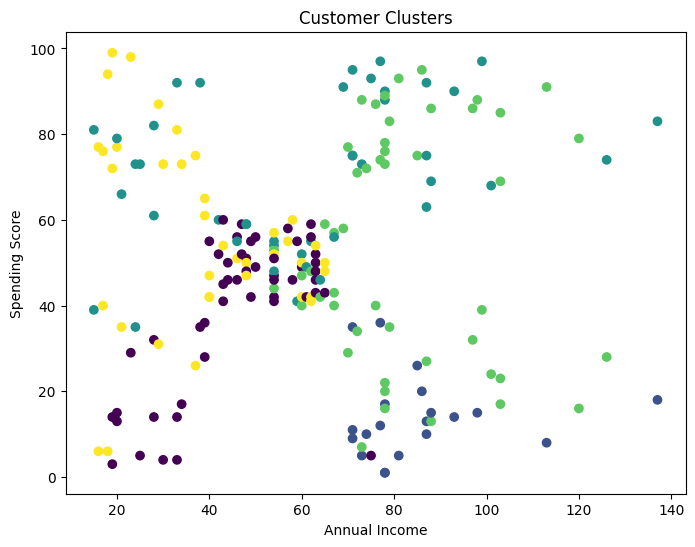

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df["Annual Income (k$)"],
            df["Spending Score (1-100)"],
            c=df["Cluster"])

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Clusters")

plt.show()

In [18]:
print(df["Cluster"].value_counts())

Cluster
0    51
3    49
2    42
4    38
1    20
Name: count, dtype: int64


In [19]:
cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         65.333333  0.509804  56.470588           46.098039   
1        159.500000  1.000000  39.500000           85.150000   
2        100.809524  1.000000  28.690476           60.904762   
3        151.510204  0.000000  37.897959           82.122449   
4         50.526316  0.000000  27.315789           38.842105   

         Spending Score (1-100)  
Cluster                          
0                     39.313725  
1                     14.050000  
2                     70.238095  
3                     54.448980  
4                     56.210526  


In [21]:
# Import joblib library
import joblib

# Save the trained K-Means model
joblib.dump(kmeans, "customer_segmentation_model.pkl")

# Save the StandardScaler object
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully as customer_segmentation_model.pkl")
print("Scaler saved successfully as scaler.pkl")

Model saved successfully as customer_segmentation_model.pkl
Scaler saved successfully as scaler.pkl


In [20]:
print("Project Completed Successfully.")
print("Customers have been divided into different groups using K-Means Clustering.")
print("These groups can help the shopping mall understand customer behavior.")

Project Completed Successfully.
Customers have been divided into different groups using K-Means Clustering.
These groups can help the shopping mall understand customer behavior.
